### Preorder Traversal of Binary Tree

Preorder Traversal is a method to traverse a tree such that for each node, you first visit the node itself, then traverse its left subtree, and finally traverse its right subtree.

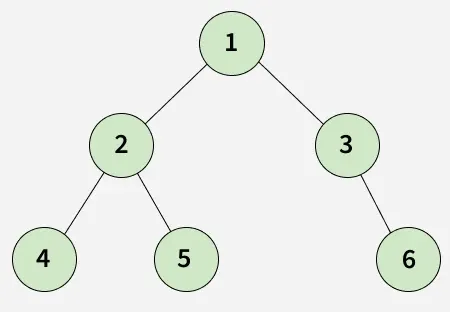

Output: [1, 2, 4, 5, 3, 6]

Explanation: Preorder Traversal (Root -> Left -> Right). 

Visit 1 -> 2 -> 4 -> 5 -> 3 -> 6, resulting in 1 2 4 5 3 6.     


#### [Approach] Using Recursion

The main idea is to traverse the tree recursively, starting from the root node, first visit the root node itself, then completely traverse the left subtree, and finally completely traverse the right subtree.

Time Complexity: O(n)

Auxiliary Space: O(h), h is the height of the tree

    In the worst case, h can be the same as n (when the tree is a skewed tree)
    In the best case, h can be the same as log n (when the tree is a complete tree)


Reference:

1. https://www.geeksforgeeks.org/dsa/preorder-traversal-of-binary-tree/


Note: Also check for applications and other uses in the above link 

In [5]:
class Node: 
    def __init__(self, key):
        self.key = key 
        self.left = None 
        self.right = None 

class BinaryTree:
    def __init__(self):
        self.root = None 

    # insert using recursive approach 
    def insert(self, key):
        if not self.root:
            self.root = Node(key)
            return 
        self._insert(self.root, key)

    def _insert(self, node, key):
        if not node.left:
            node.left = Node(key)
        elif not node.right:
            node.right = Node(key)
        else:
            # Insert recursively into left subtree (basic strategy)
            self._insert(node.left, key)

    # tree traversals - recursive approach 
    
    def preorder(self, node):
        if node: 
            print (node.key, end=" ")
            self.preorder(node.left)
            self.preorder(node.right)

  

bt = BinaryTree()
bt.insert(1)
bt.insert(2)
bt.insert(3)
bt.insert(4)
bt.insert(5)
bt.insert(6)

print("\nPreorder:", end=" ")
bt.preorder(bt.root)



Preorder: 1 2 4 6 5 3 

#### * Check the difference 

In [6]:
class Node:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None

def preOrder(node, res):
    if not node:
        return

    # Visit the current node first
    res.append(node.data)

    # Traverse the left subtree
    preOrder(node.left, res)

    # Traverse the right subtree
    preOrder(node.right, res)

if __name__ == "__main__":
    
    # Create binary tree
    #       1
    #      /  \
    #    2     3
    #   / \     \
    #  4   5     6
    
    root = Node(1)
    root.left = Node(2)
    root.right = Node(3)
    root.left.left = Node(4)
    root.left.right = Node(5)
    root.right.right = Node(6)
    
    result = []
    preOrder(root, result)

    print(*result)

1 2 4 5 3 6


#### Iterative Preorder Traversal

Given a binary tree, write an iterative function to print the Preorder traversal of the tree. 

The Preorder traversal follows the order: 

    Root → Left → Right.

Input:
           1
         /   \
        2     3
      /  \
     4    5

Output: 1 2 4 5 3

Explanation: Preorder traversal (Root->Left->Right) of the tree is 1 2 4 5 3.    

So you have 3 approaches for this problem 

[Naive Approach] Simple Iterative Preorder (with stack) - O(n) time and O(n) space
[Better Approach] Iterative Preorder with Current Pointer (with stack) - O(n) time and O(n) space
[Expected Approach] Preorder Morris Traversal - O(n) time and O(1) space

#### [Naive Approach] Simple Iterative Preorder (with stack) - O(n) time and O(n) space

Following is a simple stack based iterative process to print Preorder traversal. 

 1. Create an empty stack and push root node to stack. 
 2. Do the following while is not empty. 
 
        1. Pop an item from the stack and print it. 
        2. Push right child of a popped item to stack 
        3. Push left child of a popped item to stack

The right child is pushed before the left child to make sure that the left subtree is processed first.

In [ ]:
class Node: 
    def __init__(self, data):
        self.data = data 
        self.left = None 
        self.right = None 

def preOrder(root):
    # result list
    res = []
    # check if the tree is empty 
    if root is None:
        return res 
    # stack to hold the root
    stack = [root]    

    while stack:
        # pop the top most node
        curr = stack.pop()
        # visit it - i.e. get the data / value of the node
        res.append(curr.data)

        # push the right child first 
        if curr.right:
            stack.append(curr.right)
        # push the left child next 
        if curr.left:
            stack.append(curr.left)

    return res 

if __name__ == '__main__':
    root = Node(1)
    root.left = Node(2)
    root.right = Node(3)
    root.left.left = Node(4)
    root.left.right = Node(5)

    preorder = preOrder(root)
    print(' '.join(map(str, preorder)))

1 2 4 5 3


### [Better Approach] Iterative Preorder with Current Pointer (with stack) - O(n) time and O(n) space

In the previous solution we can see that the left child is popped as soon as it is pushed to the stack, therefore it is not required to push it into the stack. 

The idea is to start traversing the tree from the root node and keep printing the left child while exists and simultaneously, push the right child of every node in an auxiliary stack. Once we reach a null node, pop a right child from the auxiliary stack and repeat the process while the auxiliary stack is not empty. 



In [13]:
class Node:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None


def preOrder(root):
    res = []
    if root is None:
        return res

    stack = []
    curr = root

    while stack or curr:
        while curr:
            res.append(curr.data)
            if curr.right:
                stack.append(curr.right)
            curr = curr.left

        if stack:
            curr = stack.pop()

    return res


if __name__ == '__main__':
    root = Node(1)
    root.left = Node(2)
    root.right = Node(3)
    root.left.left = Node(4)
    root.left.right = Node(5)

    res = preOrder(root)

    print(' '.join(map(str, res)))

1 2 4 5 3


# [Expected Approach] Preorder Morris Traversal - O(n) time and O(1) space

Morris Traversal is a tree traversal technique that allows you to traverse a binary tree without using recursion or a stack. The Preorder Morris Traversal algorithm works by manipulating the tree's pointers, specifically by utilizing the inorder predecessor of each node.

Algorithm for Preorder Morris Traversal:

1. If the left child of the current node is NULL:

    Print the current node's data (since it is the root of the subtree).
    Move to the right child of the current node.

2. If the left child of the current node is NOT NULL:

    Find the inorder predecessor of the current node: The inorder predecessor is the rightmost node of the left subtree of the current node.

Two cases arise:

a) The right child of the inorder predecessor already points to the current node:

    This means we've already visited this node, so we can set the right child of the inorder predecessor to NULL.
    Move to the right child of the current node.

b) The right child of the inorder predecessor is NULL:

    Set the right child of the inorder predecessor to point to the current node.
    Print the current node's data.
    Move to the left child of the current node (this is the new node to visit next).

3. Repeat the process until the current node is NULL.


https://www.geeksforgeeks.org/dsa/iterative-preorder-traversal/